# Student Performance Prediction System

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
df = pd.read_csv("dataset/Student_performance_data.csv")

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== DATASET SHAPE ==========")
print("Number of rows and columns:", df.shape)

print("\n========== COLUMN NAMES ==========")
print(df.columns)

print("\n========== DATASET INFORMATION ==========")
df.info()

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())


========== FIRST 5 ROWS ==========
   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929

In [3]:
df = df.drop("StudentID", axis=1)

print("\n========== DUPLICATE ROWS ==========")
print("Number of duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("\n========== DATASET AFTER PREPROCESSING ==========")
print("Rows and columns:", df.shape)

print("\n========== MISSING VALUES AFTER PREPROCESSING ==========")
print(df.isnull().sum())


========== DUPLICATE ROWS ==========
Number of duplicate rows: 0

========== DATASET AFTER PREPROCESSING ==========
Rows and columns: (2392, 14)

========== MISSING VALUES AFTER PREPROCESSING ==========
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


In [4]:
X = df.drop(["GPA", "GradeClass"], axis=1)
y = df["GradeClass"]

print("\n========== FEATURES (X) ==========")
print(X.columns)

print("\n========== TARGET (y) ==========")
print(y.name)

print("\n========== FEATURE SHAPE ==========")
print(X.shape)

print("\n========== TARGET SHAPE ==========")
print(y.shape)


========== FEATURES (X) ==========
Index(['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly',
       'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports',
       'Music', 'Volunteering'],
      dtype='str')

========== TARGET (y) ==========
GradeClass

========== FEATURE SHAPE ==========
(2392, 12)

========== TARGET SHAPE ==========
(2392,)


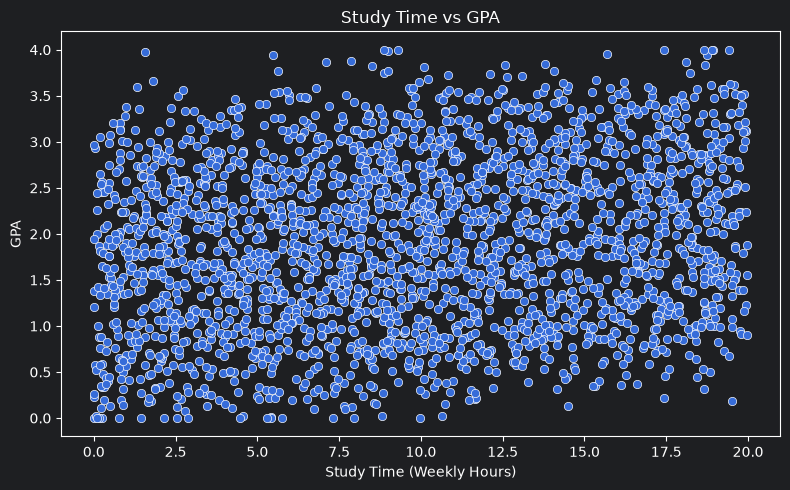

In [5]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="StudyTimeWeekly",
    y="GPA"
)

plt.title("Study Time vs GPA")
plt.xlabel("Study Time (Weekly Hours)")
plt.ylabel("GPA")

plt.tight_layout()
plt.show()

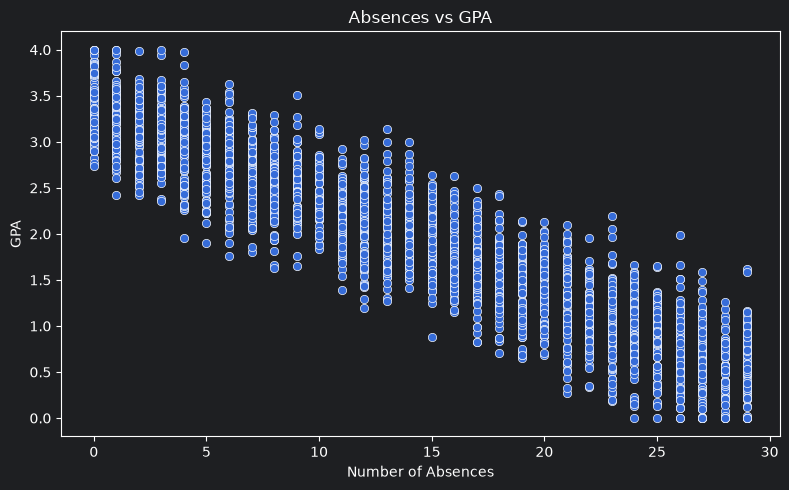

In [6]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Absences",
    y="GPA"
)

plt.title("Absences vs GPA")
plt.xlabel("Number of Absences")
plt.ylabel("GPA")

plt.tight_layout()
plt.show()

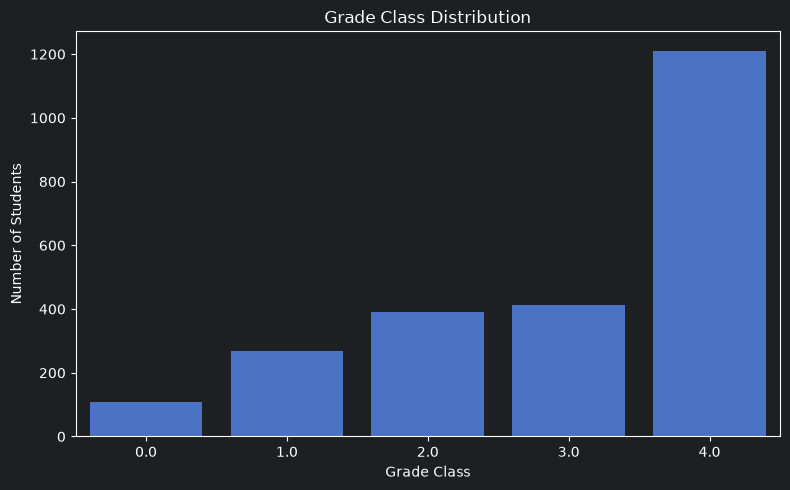

In [7]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="GradeClass"
)

plt.title("Grade Class Distribution")
plt.xlabel("Grade Class")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [10]:
X = df[
    [
        "Age",
        "Gender",
        "Ethnicity",
        "ParentalEducation",
        "StudyTimeWeekly",
        "Absences",
        "Tutoring",
        "ParentalSupport",
        "Extracurricular",
        "Sports",
        "Music",
        "Volunteering"
    ]
]

y = df["GradeClass"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n========== DATA SPLIT ==========")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


========== DATA SPLIT ==========
Training data: (1913, 12)
Testing data: (479, 12)


In [11]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)


decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)


naive_bayes_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
])

naive_bayes_model.fit(X_train, y_train)


svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

svm_model.fit(X_train, y_train)

print("\n========== MODEL TRAINING COMPLETE ==========")
print("Logistic Regression: Trained")
print("Decision Tree: Trained")
print("Naive Bayes: Trained")
print("SVM: Trained")


========== MODEL TRAINING COMPLETE ==========
Logistic Regression: Trained
Decision Tree: Trained
Naive Bayes: Trained
SVM: Trained


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_pred_logistic = logistic_model.predict(X_test)
y_pred_tree = decision_tree_model.predict(X_test)
y_pred_nb = naive_bayes_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
decision_tree_accuracy = accuracy_score(y_test, y_pred_tree)
naive_bayes_accuracy = accuracy_score(y_test, y_pred_nb)
svm_accuracy = accuracy_score(y_test, y_pred_svm)

In [13]:
print("\n========== LOGISTIC REGRESSION ==========")

print("Accuracy:",
      accuracy_score(y_test, y_pred_logistic))

print("Precision:",
      precision_score(y_test, y_pred_logistic,
                      average="weighted", zero_division=0))

print("Recall:",
      recall_score(y_test, y_pred_logistic,
                   average="weighted", zero_division=0))

print("F1-Score:",
      f1_score(y_test, y_pred_logistic,
               average="weighted", zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))


========== LOGISTIC REGRESSION ==========
Accuracy: 0.7265135699373695
Precision: 0.7159440409538269
Recall: 0.7265135699373695
F1-Score: 0.7149633884557203
Confusion Matrix:
[[  3   6   4   4   4]
 [  6  23  20   3   2]
 [  0  10  53  12   3]
 [  0   1  26  39  17]
 [  0   2   3   8 230]]


In [14]:
print("\n========== DECISION TREE ==========")

print("Accuracy:",
      accuracy_score(y_test, y_pred_tree))

print("Precision:",
      precision_score(y_test, y_pred_tree,
                      average="weighted", zero_division=0))

print("Recall:",
      recall_score(y_test, y_pred_tree,
                   average="weighted", zero_division=0))

print("F1-Score:",
      f1_score(y_test, y_pred_tree,
               average="weighted", zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))


========== DECISION TREE ==========
Accuracy: 0.5803757828810021
Precision: 0.6126040209548544
Recall: 0.5803757828810021
F1-Score: 0.59310510722032
Confusion Matrix:
[[  5   6   2   3   5]
 [  6  28  10   6   4]
 [  4  22  30  18   4]
 [  2   5  26  33  17]
 [  6  14  10  31 182]]


In [15]:
print("\n========== NAIVE BAYES ==========")

print("Accuracy:",
      accuracy_score(y_test, y_pred_nb))

print("Precision:",
      precision_score(y_test, y_pred_nb,
                      average="weighted", zero_division=0))

print("Recall:",
      recall_score(y_test, y_pred_nb,
                   average="weighted", zero_division=0))

print("F1-Score:",
      f1_score(y_test, y_pred_nb,
               average="weighted", zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))


========== NAIVE BAYES ==========
Accuracy: 0.6722338204592901
Precision: 0.6646930512127437
Recall: 0.6722338204592901
F1-Score: 0.6526536610620574
Confusion Matrix:
[[  1   8   5   3   4]
 [  1  13  34   4   2]
 [  0  11  53  11   3]
 [  0   4  29  30  20]
 [  0   2   3  13 225]]


In [16]:
print("\n========== SUPPORT VECTOR MACHINE ==========")

print("Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print("Precision:",
      precision_score(y_test, y_pred_svm,
                      average="weighted", zero_division=0))

print("Recall:",
      recall_score(y_test, y_pred_svm,
                   average="weighted", zero_division=0))

print("F1-Score:",
      f1_score(y_test, y_pred_svm,
               average="weighted", zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))


========== SUPPORT VECTOR MACHINE ==========
Accuracy: 0.697286012526096
Precision: 0.7058123960553488
Recall: 0.697286012526096
F1-Score: 0.6884818352421721
Confusion Matrix:
[[  2   7   4   4   4]
 [  1  25  26   0   2]
 [  0   6  50  19   3]
 [  0   1  25  38  19]
 [  0   2   4  18 219]]


<Figure size 700x600 with 0 Axes>

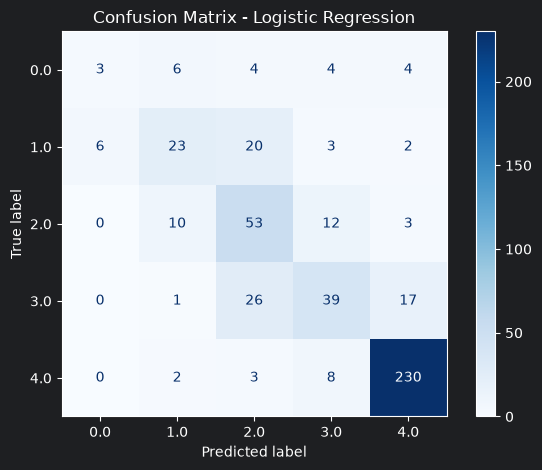

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.savefig("images/confusion_matrix_logistic.png")
plt.show()

<Figure size 700x600 with 0 Axes>

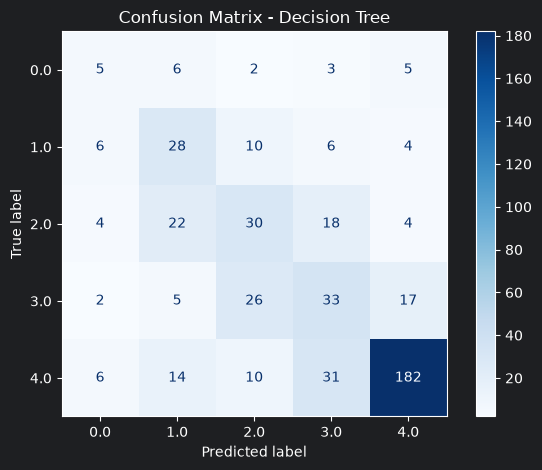

In [18]:
plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    cmap="Blues"
)

plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.savefig("images/confusion_matrix_decision_tree.png")
plt.show()

<Figure size 700x600 with 0 Axes>

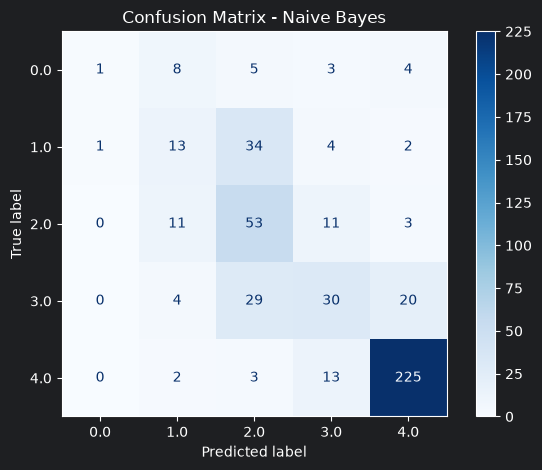

In [19]:
plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    cmap="Blues"
)

plt.title("Confusion Matrix - Naive Bayes")
plt.tight_layout()
plt.savefig("images/confusion_matrix_naive_bayes.png")
plt.show()

<Figure size 700x600 with 0 Axes>

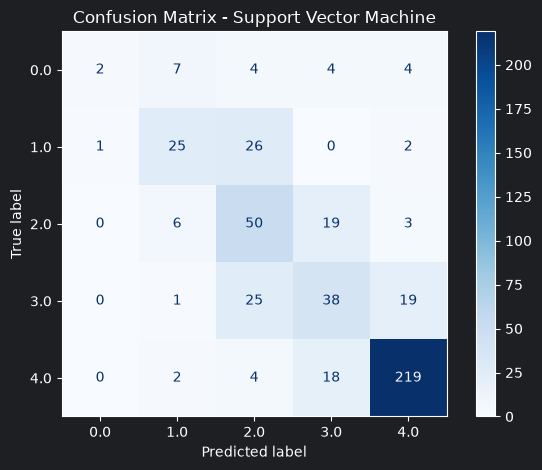

In [20]:
plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    cmap="Blues"
)

plt.title("Confusion Matrix - Support Vector Machine")
plt.tight_layout()
plt.savefig("images/confusion_matrix_svm.png")
plt.show()

In [21]:
model_names = [
    "Logistic Regression",
    "Decision Tree",
    "Naive Bayes",
    "SVM"
]

model_accuracies = [
    logistic_accuracy,
    decision_tree_accuracy,
    naive_bayes_accuracy,
    svm_accuracy
]

print("\n========== MODEL COMPARISON ==========")

for name, accuracy in zip(model_names, model_accuracies):
    print(f"{name}: {accuracy:.4f}")

best_model_index = model_accuracies.index(max(model_accuracies))

print("\n========== BEST MODEL ==========")
print("Best Model:", model_names[best_model_index])
print("Best Accuracy:", f"{model_accuracies[best_model_index]:.4f}")


========== MODEL COMPARISON ==========
Logistic Regression: 0.7265
Decision Tree: 0.5804
Naive Bayes: 0.6722
SVM: 0.6973

========== BEST MODEL ==========
Best Model: Logistic Regression
Best Accuracy: 0.7265


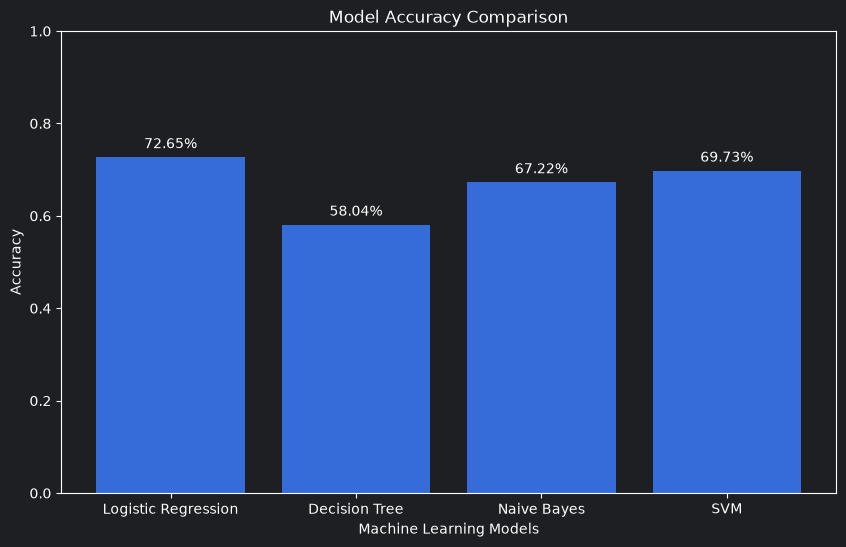

In [22]:
plt.figure(figsize=(10, 6))

plt.bar(model_names, model_accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, accuracy in enumerate(model_accuracies):
    plt.text(i, accuracy + 0.02, f"{accuracy:.2%}", ha="center")

plt.show()

In [23]:
import joblib
import os

model_folder = "model"
os.makedirs(model_folder, exist_ok=True)

joblib.dump(
    logistic_model,
    os.path.join(model_folder, "student_performance_model.pkl")
)

print("MODEL SAVED SUCCESSFULLY!")

MODEL SAVED SUCCESSFULLY!


In [24]:
sample_student = pd.DataFrame([{
    "Age": 17,
    "Gender": 1,
    "Ethnicity": 0,
    "ParentalEducation": 2,
    "StudyTimeWeekly": 10.0,
    "Absences": 5,
    "Tutoring": 1,
    "ParentalSupport": 2,
    "Extracurricular": 1,
    "Sports": 1,
    "Music": 0,
    "Volunteering": 0
}])

prediction = logistic_model.predict(sample_student)

print("Predicted Grade Class:", prediction[0])

Predicted Grade Class: 1.0


## Conclusion

The Student Performance Prediction System successfully analyzes student data and uses multiple machine learning classification algorithms to predict grade classes. Among the tested models, Logistic Regression achieved the highest accuracy. The trained model was saved and successfully used to make a prediction for a sample student.
